In [43]:
x = [1,2,3,10]
y = [10, 20, 30, 40]

z = []
for a,b in zip(x,y):
    t = a+b
    z.append(t)
    
print(z)

[11, 22, 33, 50]


In [44]:
x = [1,2,3,10]
y = [10, 20, 30, 40]

z = [a + b for a,b in zip(x,y)]

print(z)

[11, 22, 33, 50]


In [2]:
x = [1,2,3,10]
y = [10, 20, 30, 40]

zm = list(map(lambda a,b: a + b, x,y))

print(zm)

[11, 22, 33, 50]


In [27]:
import numpy as np

def game():
    c = ['R','P','S'] #choices
    
    print("Rock, Paper, Scissors")
    print("R for Rock, P for Paper, S for Scissors")
    play = input("Choose:")
    
    if play not in c:
        print("Invalid")
        return #when the player does not choose an available character
    
    comp = np.random.choice(c) #the computer chooses randomly
    print(f'Computer:{comp}')
    
    if play == comp:
        print("Tie!")
        game()
    elif (play == 'R' and comp == 'P'):
        print("Computer Wins!")
    elif (play == 'R' and comp == 'S'):
        print("Player Wins!")
    elif (play == 'P' and comp == 'S'):
        print("Computer Wins!")
    elif (play == 'P' and comp == 'R'):
        print("Player Wins!")
    elif (play == 'S' and comp == 'R'):
        print("Computer Wins!")
    else:
        print("Player Wins!")
        
        #checking who wins the game
        
game()

Rock, Paper, Scissors
R for Rock, P for Paper, S for Scissors
Choose:P
Computer:P
Tie!
Rock, Paper, Scissors
R for Rock, P for Paper, S for Scissors
Choose:R
Computer:R
Tie!
Rock, Paper, Scissors
R for Rock, P for Paper, S for Scissors
Choose:P
Computer:S
Computer Wins!


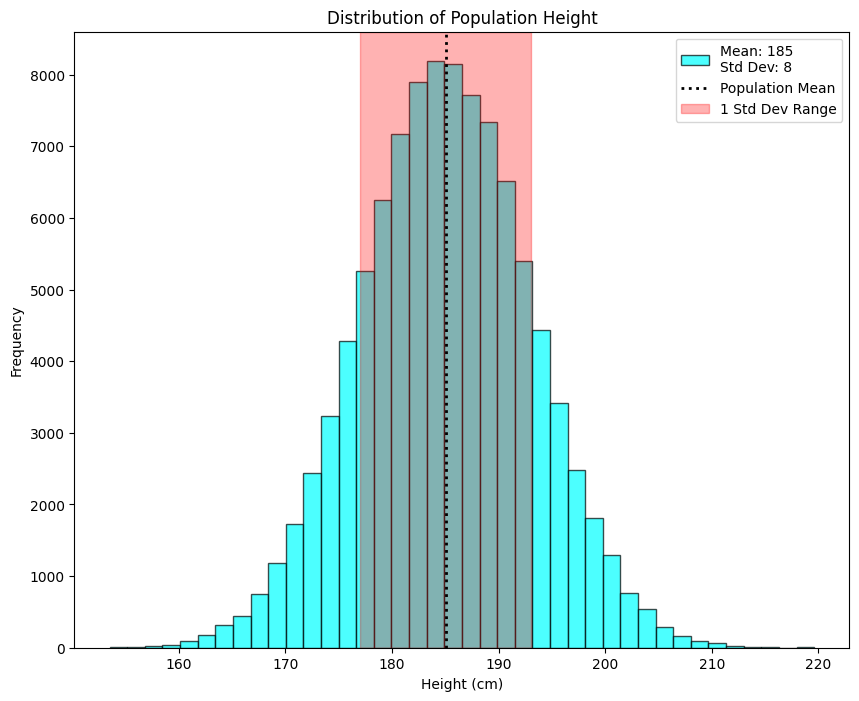

Probability x <= 185: 0.5
Probability 177 <= h <= 193: 0.6826894921370859


In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

mu = 185
sigma = 8
n = 100000

data = np.random.normal(mu, sigma, n)

mud = np.mean(data)
sigmad = np.std(data)

plt.figure(figsize=(10,8))
counts, bins, patches = plt.hist(data, bins=40, color='cyan', edgecolor="black", alpha=0.7, label=f'Mean: {mu}\nStd Dev: {sigma}')

plt.axvline(mud, color='black', linestyle='dotted', linewidth=2, label='Population Mean')
 
plt.axvspan(mud - sigmad, mud + sigmad, color='red', alpha=0.3, label="1 Std Dev Range")

plt.title('Distribution of Population Height')
plt.xlabel('Height (cm)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

probs = norm.cdf(mu,mu,sigma)

print(f'Probability x <= {mu}: {probs}')

prob1 = norm.cdf(mu + sigma, mu, sigma) - norm.cdf(mu - sigma, mu, sigma)

print(f'Probability {mu-sigma} <= h <= {mu+sigma}: {prob1}')

In [47]:
import numpy as np

def monte():
    f = input("Function:")
    a = float(input("Lower Boundry:"))
    b = float(input("Upper Boundry:"))
    
    n = 100000
    x = np.random.uniform(a,b,n)
    
    y = eval(f, {"x": x, "np": np})
    
    integral = (b - a) * np.mean(y)
    
    print(integral)

monte()

Function:x
Lower Boundry:0
Upper Boundry:1
0.5000058135772725


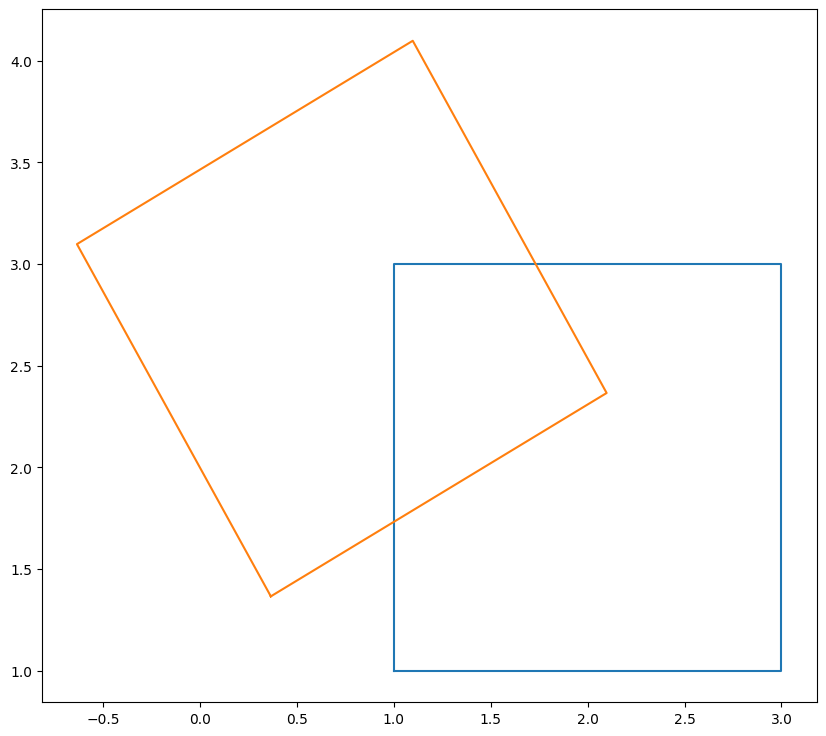

In [6]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1,3,3,1,1])
y = np.array([1,1,3,3,1])

th = 30
thr = np.radians(th)

r = np.exp(1j * thr)

z = x +1j * y

zr = z * r

xr = zr.real
yr = zr.imag

plt.figure(figsize=(10,9))
plt.plot(x,y,label='Square')
plt.plot(xr,yr,label='Rotated Square')


In [9]:
import numpy as np

def funcfilter(func, seq):
    arr = np.asarray(seq)
    
    filt = arr[arr > 0]
    
    return func(filt)

sq = np.array([-100, -10, 0, 10, 100])
result = funcfilter(np.log10, sq)
print("Result log10:", result)

n = 100
print(funcfilter(np.log10,n))

Result log10: [1. 2.]
[2.]


In [8]:
from astropy.cosmology import Planck18
import numpy as np
from scipy.integrate import quad
import astropy.units as u

H0 = Planck18.H0.value
Om0 = Planck18.Om0
Ode0 = Planck18.Ode0

def H(z):
    return H0 * np.sqrt(Om0 * (1 + z)**3 + Ode0)

def inte(zp):
    return 1  / ((1 + zp) * H(zp))

def time(z):
    r,e = quad(inte,0,z)
    t = r * (u.km / u.s / u.Mpc)**-1
    tg = t.to(u.Gyr).value
    return tg

zt = 2
m = time(zt)
print(f'{m} Gyr')

10.526203408163191 Gyr


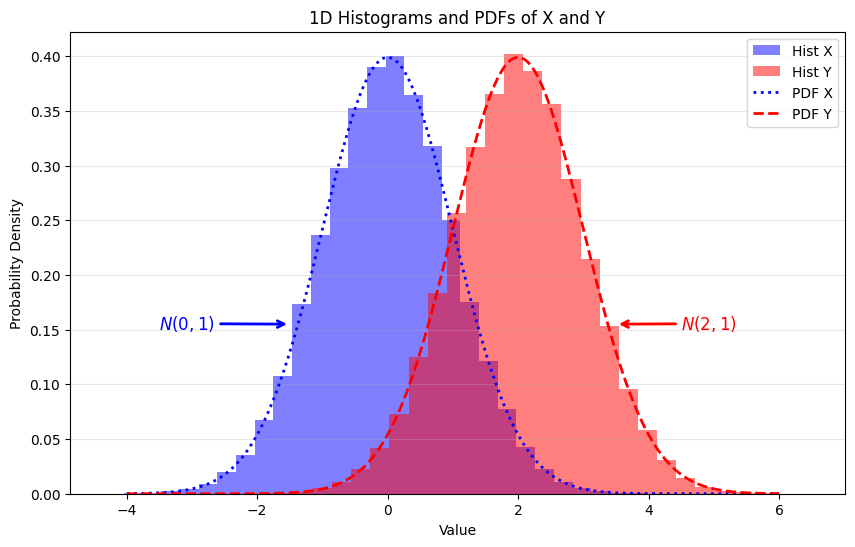

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x = np.random.normal(loc=0, scale=1, size=100000)
y = np.random.normal(loc=2, scale=1, size=100000)

plt.figure(figsize=(10, 6))

plt.hist(x, bins=30, density=True, alpha=0.5, color='blue', label='Hist X')
plt.hist(y, bins=30, density=True, alpha=0.5, color='red', label='Hist Y')

xaxis = np.linspace(-4, 6, 1000)
plt.plot(xaxis, norm.pdf(xaxis, 0, 1), color='blue', lw=2, label='PDF X', linestyle='dotted')
plt.plot(xaxis, norm.pdf(xaxis, 2, 1), color='red', lw=2, label='PDF Y', linestyle='dashed')

plt.annotate(r'$N(0, 1)$', xy=(-1.5, 0.155),xytext=(-3.5, 0.15),arrowprops=dict(arrowstyle='->', color='blue', lw=2),fontsize=12, color='blue')

plt.annotate(r'$N(2, 1)$', xy=(3.5, 0.155),xytext=(4.5, 0.15),arrowprops=dict(arrowstyle='->', color='red', lw=2),fontsize=12, color='red')

plt.title('1D Histograms and PDFs of X and Y')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

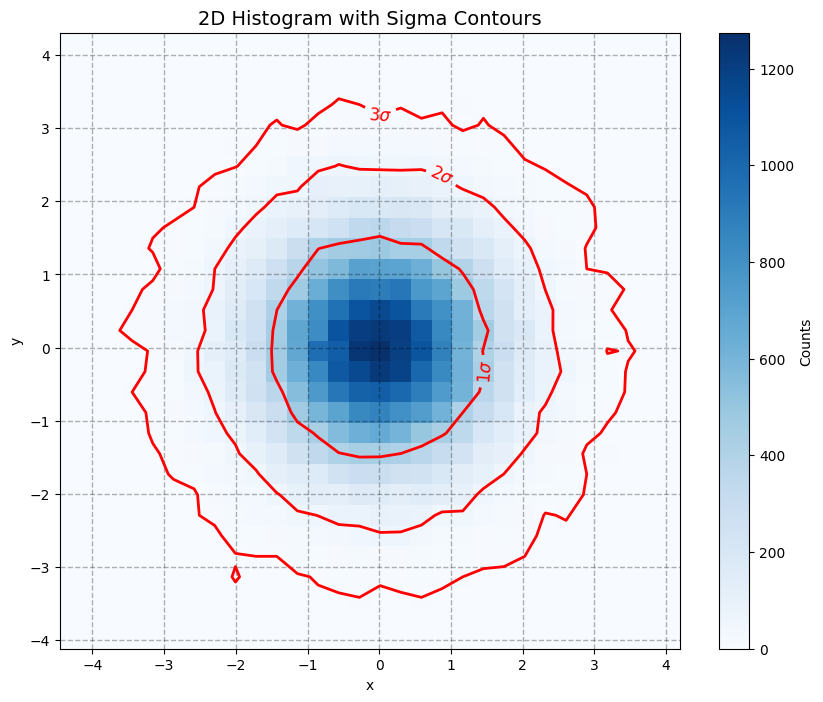

In [56]:
import numpy as np
import matplotlib.pyplot as plt

x = np.random.normal(0, 1, 100000)
y = np.random.normal(0, 1, 100000)

plt.figure(figsize=(10, 8))

counts, xedges, yedges, image = plt.hist2d(x, y, bins=30, cmap='Blues')
plt.colorbar(label='Counts')

histf = np.sort(counts.flatten())[::-1]
csum = np.cumsum(histf)
csum /= csum[-1]

l1sig = histf[np.searchsorted(csum, 0.68)]
l2sig = histf[np.searchsorted(csum, 0.95)]
l3sig = histf[np.searchsorted(csum, 0.997)]

xcenter = (xedges[:-1] + xedges[1:]) / 2
ycenter = (yedges[:-1] + yedges[1:]) / 2

CS = plt.contour(xcenter, ycenter, counts.T, levels=[l3sig, l2sig, l1sig], 
                 colors='red', linestyles='solid', linewidths=2)

fmt = {l3sig: r'3$\sigma$', l2sig: r'2$\sigma$', l1sig: r'1$\sigma$'}

plt.clabel(CS, fmt=fmt, inline=True, fontsize=12)

plt.grid(True, color='black', linewidth=1, linestyle='--', alpha=0.3)
plt.title('2D Histogram with Sigma Contours', fontsize=14)
plt.xlabel('x')
plt.ylabel('y')

plt.show()